# Assignment 5 - Step 1: Mean-Reversion Evidence

This notebook is the first research step for the Swiss equity strategy. The goal is deliberately narrow: before building a complete portfolio, we check whether Swiss stocks show short-horizon mean reversion.

The question is:

> If a stock underperforms its Swiss peers over a recent daily, weekly, or monthly period, does it tend to outperform in the following period?

We test the idea in a simple cross-sectional setting. At each evaluation date, stocks are ranked by a reversal signal, then we ask whether that rank predicts next-period returns. The notebook follows this order:

1. load the market, JKP, and SPI datasets;
2. build clean return and presence matrices;
3. define raw, volatility-scaled, and market-neutral reversal signals;
4. evaluate the scores with information coefficients, cross-sectional regressions, and HML portfolios;
5. inspect market exposure and tail events.

The tests are gross of transaction costs. That is important because short-horizon reversal usually trades often.


In [5]:
from pathlib import Path
from typing import Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from IPython.display import display
from scipy import stats

pd.options.display.float_format = "{:,.4f}".format

STUDY_START_DATE = pd.Timestamp("2010-01-01")
GROUPING_PERIODS = ["D", "W", "M"]

BETA_WINDOW_DAYS = 252
MIN_BETA_OBSERVATIONS = 126
MIN_STOCKS_PER_CROSS_SECTION = 30
HML_PORTFOLIO_FRACTION = 0.05
MIN_REALIZED_LEG_COVERAGE = 0.80
MAX_ABS_DAILY_RETURN_ALERT = 0.50

VOL_LOOKBACK_BY_PERIOD = {"D": 252, "W": 52, "M": 12}
MIN_DAYS_BY_PERIOD = {"D": 1, "W": 3, "M": 10}
RESAMPLE_FREQ = {"D": None, "W": "W-FRI", "M": "ME"}
PERIODS_PER_YEAR = {"D": 252, "W": 52, "M": 12}

unknown_periods = set(GROUPING_PERIODS).difference(RESAMPLE_FREQ)
if unknown_periods:
    raise ValueError(f"Unknown grouping periods: {unknown_periods}")

if not 0 < HML_PORTFOLIO_FRACTION <= 0.5:
    raise ValueError("HML_PORTFOLIO_FRACTION must be between 0 and 0.5.")

if not 0 < MIN_REALIZED_LEG_COVERAGE <= 1:
    raise ValueError("MIN_REALIZED_LEG_COVERAGE must be between 0 and 1.")


def find_project_root(start: Optional[Path] = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "data").is_dir() and (candidate / "src").is_dir():
            return candidate
    raise FileNotFoundError("Could not find project root with data/ and src/.")


def set_datetime_level(df: pd.DataFrame, level: str = "date") -> pd.DataFrame:
    df = df.copy().sort_index()
    level_number = df.index.names.index(level)
    df.index = df.index.set_levels(pd.to_datetime(df.index.levels[level_number]), level=level_number)
    return df


def market_wide(market_panel: pd.DataFrame, field: str) -> pd.DataFrame:
    df = market_panel[field].unstack("id").sort_index()
    return df.loc[:, pd.Index(df.columns).notna()]


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data"

market_data = set_datetime_level(pd.read_parquet(DATA_DIR / "market_data.parquet"))
market_data_clean = market_data[~market_data.index.duplicated(keep="last")]

prices = market_wide(market_data_clean, "price")
mktcaps = market_wide(market_data_clean, "mktcap")
liquidity = market_wide(market_data_clean, "liquidity")
sectors = market_wide(market_data_clean, "sector")
active_stock = prices.notna()

market_overview = pd.DataFrame(
    {
        "rows": [len(market_data_clean)],
        "stocks": [prices.shape[1]],
        "start": [prices.index.min()],
        "end": [prices.index.max()],
        "dates": [prices.shape[0]],
    },
    index=["market_data"],
)

active_observations = active_stock.sum().sum()
missing_summary = pd.DataFrame(
    {
        "missing_count": {
            "price": 0,
            "mktcap": (mktcaps.isna() & active_stock).sum().sum(),
            "liquidity": (liquidity.isna() & active_stock).sum().sum(),
            "sector": (sectors.isna() & active_stock).sum().sum(),
        }
    }
)
missing_summary["missing_pct"] = missing_summary["missing_count"] / active_observations

jkp_data = set_datetime_level(pd.read_parquet(DATA_DIR / "jkp_data.parquet"))
jkp_data_clean = jkp_data[~jkp_data.index.duplicated(keep="last")]

principal_factors = {
    "Momentum (ret_12_1)": "ret_12_1",
    "Value (be_me)": "be_me",
    "Profitability (qmj_prof)": "qmj_prof",
    "Quality (qmj)": "qmj",
    "Investment (inv_gr1)": "inv_gr1",
}
available_factors = {name: col for name, col in principal_factors.items() if col in jkp_data_clean.columns}
factor_wide = {name: jkp_data_clean[col].unstack("id").sort_index() for name, col in available_factors.items()}

all_factor_mask = None
for df in factor_wide.values():
    all_factor_mask = df.notna() if all_factor_mask is None else (all_factor_mask & df.notna())

factor_counts = pd.DataFrame({name: df.notna().sum(axis=1) for name, df in factor_wide.items()})
factor_counts["All selected factors"] = all_factor_mask.sum(axis=1)

first_factor_dates = pd.Series(
    {
        f"first_date_with_{threshold}_stocks_all_selected_factors": factor_counts.index[
            factor_counts["All selected factors"] >= threshold
        ].min()
        for threshold in [50, 100, 150]
    }
)

print("Market sample")
display(market_overview)
print("Missing market fields inside the active-price sample")
display(missing_summary)
print("Selected JKP factor availability")
display(factor_counts.describe())
display(first_factor_dates.to_frame("date"))


Market sample


,rows,stocks,start,end,dates
market_data,1399476,313,1985-12-31,2024-04-30,9979


Missing market fields inside the active-price sample


,missing_count,missing_pct
price,0,0.0000
mktcap,0,0.0000
liquidity,102574,0.0738
sector,1388380,0.9984


Selected JKP factor availability


,Momentum (ret_12_1),Value (be_me),Profitability (qmj_prof),Quality (qmj),Investment (inv_gr1),All selected factors
count,460.0000,460.0000,460.0000,460.0000,460.0000,460.0000
mean,146.9761,134.4935,126.1870,100.0326,96.5630,70.1674
std,58.0516,63.8409,66.1055,65.8418,47.2913,45.5192
min,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000
25%,121.7500,96.0000,77.7500,53.7500,68.0000,40.5000
50%,175.0000,171.0000,162.0000,135.0000,122.0000,100.0000
75%,186.2500,176.0000,174.0000,159.0000,129.0000,110.0000
max,206.0000,193.0000,190.0000,170.0000,139.0000,120.0000


,date
first_date_with_50_stocks_all_selected_factors,1998-05-31
first_date_with_100_stocks_all_selected_factors,2003-09-30
first_date_with_150_stocks_all_selected_factors,NaT


## Return Panels and Reversal Signals

The raw stock return is computed directly from prices, without filling missing prices:

$$
r_{i,d} = \frac{P_{i,d}}{P_{i,d-1}} - 1.
$$

Because a raw return can partly reflect market movement, we also build a market-neutral return. The beta used on day $d$ is estimated only from past data and then lagged:

$$
\beta_{i,d-1} =
\frac{\operatorname{Cov}(r_{i,\tau}, r^{SPI}_{\tau})}
     {\operatorname{Var}(r^{SPI}_{\tau})}.
$$

The residual return is:

$$
r^{res}_{i,d} = r_{i,d} - \beta_{i,d-1} r^{SPI}_d.
$$

For weekly and monthly tests, daily returns are compounded inside each period:

$$
r_{i,t} = \prod_{d \in t} (1 + r_{i,d}) - 1.
$$

A stock is eligible only if it is present at the evaluation date. On that eligible universe, we create three sign-aware reversal scores. The minus sign is important: it makes the score easy to read, because a higher score always means a stronger rebound candidate.

$$
\text{Score}^{raw}_{i,t} = -r_{i,t},
$$

$$
\text{Score}^{vol}_{i,t} = -\frac{r_{i,t}}{\sigma_{i,t}},
$$

$$
\text{Score}^{res}_{i,t} = -\frac{r^{res}_{i,t}}{\sigma^{res}_{i,t}}.
$$

With this convention, recent losers receive high scores and recent winners receive low scores. If mean reversion is present, high-score stocks should have higher next-period returns.


In [6]:
def load_spi_returns(path: Path) -> pd.Series:
    spi = pd.read_csv(path / "spi_index.csv", index_col=0, header=0, parse_dates=True, date_format="%d/%m/%Y").squeeze(
        "columns"
    )
    spi.index = pd.DatetimeIndex(spi.index)
    spi.name = "spi_return"
    return spi.sort_index()


def aggregate_returns(daily_returns: pd.DataFrame | pd.Series, grouping_period: str, min_days: int):
    freq = RESAMPLE_FREQ[grouping_period]
    if freq is None:
        return daily_returns.copy()
    return (1 + daily_returns).resample(freq).prod(min_count=min_days) - 1


def aggregate_presence(daily_presence: pd.DataFrame, grouping_period: str) -> pd.DataFrame:
    freq = RESAMPLE_FREQ[grouping_period]
    if freq is None:
        return daily_presence.copy()
    return daily_presence.resample(freq).last().fillna(False).astype(bool)


# Raw daily stock returns. Missing prices are not filled, so we do not create artificial returns.
daily_stock_returns = prices.pct_change(fill_method=None)
daily_spi_returns = load_spi_returns(DATA_DIR).reindex(daily_stock_returns.index)

# Estimate each stock's rolling SPI beta using past observations only.
rolling_cov = daily_stock_returns.rolling(BETA_WINDOW_DAYS, min_periods=MIN_BETA_OBSERVATIONS).cov(daily_spi_returns)
rolling_var = daily_spi_returns.rolling(BETA_WINDOW_DAYS, min_periods=MIN_BETA_OBSERVATIONS).var()
rolling_beta_lagged = rolling_cov.divide(rolling_var, axis=0).shift(1)
daily_market_neutral_returns = daily_stock_returns - rolling_beta_lagged.multiply(daily_spi_returns, axis=0)

return_values = daily_stock_returns.stack()
return_sanity = pd.Series(
    {
        "daily_stock_return_count": return_values.count(),
        "daily_stock_return_min": return_values.min(),
        "daily_stock_return_max": return_values.max(),
        "daily_stock_abs_return_gt_alert": (return_values.abs() > MAX_ABS_DAILY_RETURN_ALERT).sum(),
        "daily_spi_return_min": daily_spi_returns.min(),
        "daily_spi_return_max": daily_spi_returns.max(),
    }
)


def build_period_data(grouping_period: str) -> dict:
    # Convert daily returns into the horizon being tested: daily, weekly, or monthly.
    min_days = MIN_DAYS_BY_PERIOD[grouping_period]
    stock_returns = aggregate_returns(daily_stock_returns, grouping_period, min_days)
    market_neutral_returns = aggregate_returns(daily_market_neutral_returns, grouping_period, min_days)
    spi_returns = aggregate_returns(daily_spi_returns, grouping_period, min_days)
    presence = aggregate_presence(active_stock, grouping_period).reindex(
        index=stock_returns.index, columns=stock_returns.columns
    ).fillna(False).astype(bool)

    vol_lookback = VOL_LOOKBACK_BY_PERIOD[grouping_period]
    min_vol_periods = max(3, vol_lookback // 2)
    raw_volatility = stock_returns.rolling(vol_lookback, min_periods=min_vol_periods).std()
    residual_volatility = market_neutral_returns.rolling(vol_lookback, min_periods=min_vol_periods).std()

    # The score is formed only for stocks that are present at the evaluation date.
    tradable_at_signal = presence.reindex(index=stock_returns.index, columns=stock_returns.columns).fillna(False).astype(bool)
    target_raw = stock_returns.shift(-1)
    target_residual = market_neutral_returns.shift(-1)

    # Scores are sign-aware: high score = recent loser = stronger rebound candidate.
    signals = {
        "Raw mean reversion": ((-stock_returns).where(tradable_at_signal), target_raw),
        "Vol-scaled mean reversion": ((-stock_returns / raw_volatility).where(tradable_at_signal), target_raw),
        "Residual mean reversion": ((-market_neutral_returns / residual_volatility).where(tradable_at_signal), target_residual),
    }

    coverage = pd.DataFrame(
        {
            "present_at_evaluation": presence.sum(axis=1),
            "raw_returns": stock_returns.notna().sum(axis=1),
            "market_neutral_returns": market_neutral_returns.notna().sum(axis=1),
            "raw_and_present": (stock_returns.notna() & presence).sum(axis=1),
            "mn_and_present": (market_neutral_returns.notna() & presence).sum(axis=1),
        }
    )

    return {
        "period": grouping_period,
        "stock_returns": stock_returns,
        "market_neutral_returns": market_neutral_returns,
        "spi_returns": spi_returns,
        "presence": presence,
        "signals": signals,
        "coverage": coverage,
    }


print("Daily return sanity checks")
display(return_sanity.to_frame("value"))


Daily return sanity checks


,value
daily_stock_return_count,"1,335,432.0000"
daily_stock_return_min,-0.9477
daily_stock_return_max,9.1818
daily_stock_abs_return_gt_alert,153.0000
daily_spi_return_min,-0.0911
daily_spi_return_max,0.1058


## Tests Used to Judge the Signal

The same evaluation is repeated for the daily, weekly, and monthly horizons. For a given horizon, let $\mathcal{U}_t$ be the eligible cross-section at evaluation date $t$, and let $\text{Score}_{i,t}$ be the sign-aware reversal score for stock $i$. Because the score already includes the minus sign, high scores correspond to recent losers and low scores correspond to recent winners.

The next-period return used in the test is denoted $R_{i,t+1}$. It depends on the score being tested:

- for the raw and volatility-scaled reversal scores, $R_{i,t+1} = r_{i,t+1}$;
- for the residual reversal score, $R_{i,t+1} = r^{res}_{i,t+1}$ in the IC and regression tests;
- for HML portfolio performance, returns are always measured with tradable raw returns $r_{i,t+1}$.

The metrics are:

- **Information coefficient (IC)**: this is the Spearman rank correlation between the score and the next-period return inside the cross-section:

$$
IC_t = \rho_S\left(\{\text{Score}_{i,t}\}_{i \in \mathcal{U}_t}, \{R_{i,t+1}\}_{i \in \mathcal{U}_t}\right).
$$

A positive $IC_t$ means that higher-score stocks tend to have better next-period returns. The reported mean IC is:

$$
\overline{IC} = \frac{1}{T}\sum_{t=1}^{T} IC_t.
$$

- **Cross-sectional regression slope**: each period, we run a simple one-variable regression across stocks:

$$
R_{i,t+1} \approx \beta_t \cdot \text{Score}_{i,t}, \qquad i \in \mathcal{U}_t.
$$

The estimated slope $\hat{\beta}_t$ tells us whether the score has the expected sign. Because the score is already defined as minus the past return, mean reversion corresponds to:

$$
\hat{\beta}_t > 0.
$$

The table reports the average slope across all test dates:

$$
\overline{\beta} = \frac{1}{T}\sum_{t=1}^{T}\hat{\beta}_t.
$$

- **HML long-short return**: at date $t$, stocks are sorted by $\text{Score}_{i,t}$. The portfolio goes long the top 5% of stocks, denoted $L_t$, and short the bottom 5%, denoted $S_t$. We use gross exposure one:

$$
\sum_i |w_{i,t}| = 1,
\qquad
\sum_{i \in L_t} w_{i,t} = 0.5,
\qquad
\sum_{i \in S_t} w_{i,t} = -0.5.
$$

The next-period HML return is therefore:

$$
R^{HML}_{t+1} =
\frac{0.5}{|L_t|}\sum_{i \in L_t} r_{i,t+1}
-
\frac{0.5}{|S_t|}\sum_{i \in S_t} r_{i,t+1}.
$$

- **Turnover**: turnover is the amount of notional traded when moving from one HML portfolio to the next:

$$
\text{Turnover}_t = \sum_i |w_{i,t} - w_{i,t-1}|.
$$

- **Annualized return, volatility, and Sharpe ratio**: if $p$ is the number of periods per year and $R_t$ is the HML return series, the notebook reports:

$$
R^{ann} = \left(\prod_{t=1}^{T}(1+R_t)\right)^{p/T} - 1,
$$

$$
\sigma^{ann} = \sqrt{p}\,\operatorname{Std}(R_t),
$$

$$
\text{Sharpe} = \sqrt{p}\,\frac{\operatorname{Mean}(R_t)}{\operatorname{Std}(R_t)}.
$$

- **SPI exposure regression**: to check whether the HML return is just compensation for Swiss market exposure, we estimate:

$$
R^{HML}_{t+1} = \hat{\alpha} + \hat{\beta}^{SPI} R^{SPI}_{t+1} + \hat{\varepsilon}_{t+1}.
$$

A useful reversal signal should ideally have a positive alpha and a market beta that is not driving the whole result.


In [7]:
# Build one clean cross-section for a given date.
def score_return_frame(score: pd.DataFrame, next_return: pd.DataFrame, date) -> pd.DataFrame:
    return pd.concat({"score": score.loc[date], "next_return": next_return.loc[date]}, axis=1).replace(
        [np.inf, -np.inf], np.nan
    ).dropna()


def study_dates(score: pd.DataFrame, next_return: pd.DataFrame):
    dates = score.index.intersection(next_return.index)
    return dates[dates >= STUDY_START_DATE]


def ic_summary(
    score: pd.DataFrame,
    next_return: pd.DataFrame,
    min_stocks: int = MIN_STOCKS_PER_CROSS_SECTION,
) -> tuple[pd.Series, dict]:
    ics = {}
    for date in study_dates(score, next_return):
        df = score_return_frame(score, next_return, date)
        if len(df) >= min_stocks and df["score"].nunique() > 1 and df["next_return"].nunique() > 1:
            ics[date] = stats.spearmanr(df["score"], df["next_return"]).statistic

    ic = pd.Series(ics, name="IC").dropna()
    test = stats.ttest_1samp(ic, 0, nan_policy="omit") if len(ic) else None
    return ic, {
        "mean_ic": ic.mean(),
        "ic_tstat": test.statistic if test else np.nan,
        "ic_pvalue": test.pvalue if test else np.nan,
        "ic_hit_rate": (ic > 0).mean() if len(ic) else np.nan,
        "n_periods": len(ic),
    }


def cs_regression_summary(
    score: pd.DataFrame,
    next_return: pd.DataFrame,
    min_stocks: int = MIN_STOCKS_PER_CROSS_SECTION,
) -> dict:
    rows = []
    for date in study_dates(score, next_return):
        df = score_return_frame(score, next_return, date)
        if len(df) >= min_stocks and df["score"].nunique() > 1:
            # Slope of next return on score. Positive slope supports mean reversion.
            res = stats.linregress(df["score"], df["next_return"])
            rows.append({"date": date, "slope": res.slope, "r2": res.rvalue**2})

    out = pd.DataFrame(rows)
    if out.empty:
        return {"avg_slope": np.nan, "slope_tstat": np.nan, "slope_pvalue": np.nan, "avg_r2": np.nan, "n_periods": 0}

    test = stats.ttest_1samp(out["slope"], 0, nan_policy="omit")
    return {
        "avg_slope": out["slope"].mean(),
        "slope_tstat": test.statistic,
        "slope_pvalue": test.pvalue,
        "avg_r2": out["r2"].mean(),
        "n_periods": len(out),
    }


def predictive_study(signals: dict) -> tuple[pd.DataFrame, pd.DataFrame, dict]:
    ic_rows = {}
    reg_rows = {}
    ic_series = {}
    for name, (score, next_return) in signals.items():
        ic_series[name], ic_rows[name] = ic_summary(score, next_return)
        reg_rows[name] = cs_regression_summary(score, next_return)
    return pd.DataFrame(ic_rows).T, pd.DataFrame(reg_rows).T, ic_series


def hml_portfolio(
    score: pd.DataFrame,
    pnl_returns: pd.DataFrame,
    min_stocks: int = MIN_STOCKS_PER_CROSS_SECTION,
    leg_fraction: float = HML_PORTFOLIO_FRACTION,
    min_realized_leg_coverage: float = MIN_REALIZED_LEG_COVERAGE,
) -> tuple[pd.Series, pd.DataFrame, pd.DataFrame]:
    # Portfolio PnL is evaluated with raw tradable returns, shifted to the next period.
    target = pnl_returns.shift(-1)
    returns = {}
    positions = {}
    coverage_rows = []

    for date in study_dates(score, target):
        score_row = score.loc[date].replace([np.inf, -np.inf], np.nan).dropna()
        n_leg = int(np.floor(len(score_row) * leg_fraction))
        if len(score_row) < min_stocks or n_leg < 1 or score_row.nunique() <= 1:
            continue

        # Low-score stocks are recent winners, high-score stocks are recent losers.
        ranked = score_row.sort_values()
        short_ids = ranked.head(n_leg).index
        long_ids = ranked.tail(n_leg).index

        target_row = target.loc[date]
        long_returns = target_row.reindex(long_ids).dropna()
        short_returns = target_row.reindex(short_ids).dropna()
        long_coverage = len(long_returns) / n_leg
        short_coverage = len(short_returns) / n_leg
        coverage_rows.append(
            {
                "date": date,
                "n_signal": len(score_row),
                "n_leg": n_leg,
                "long_coverage": long_coverage,
                "short_coverage": short_coverage,
            }
        )

        if long_coverage < min_realized_leg_coverage or short_coverage < min_realized_leg_coverage:
            continue

        returns[date] = 0.5 * long_returns.mean() - 0.5 * short_returns.mean()

        weight = pd.Series(0.0, index=score.columns)
        weight.loc[long_ids] = 0.5 / n_leg
        weight.loc[short_ids] = -0.5 / n_leg
        positions[date] = weight

    returns = pd.Series(returns, name="hml").dropna()
    positions = pd.DataFrame(positions).T.sort_index()
    coverage = pd.DataFrame(coverage_rows).set_index("date") if coverage_rows else pd.DataFrame()
    return returns, positions, coverage


def portfolio_turnover(positions: pd.DataFrame) -> pd.Series:
    if positions.empty:
        return pd.Series(dtype=float)
    turnover = positions.fillna(0).diff().abs().sum(axis=1)
    turnover.iloc[0] = positions.iloc[0].abs().sum()
    return turnover.rename("turnover")


def max_drawdown(returns: pd.Series) -> float:
    wealth = (1 + returns).cumprod()
    return (wealth / wealth.cummax() - 1).min()


def hml_summary(
    returns: pd.Series,
    turnover: pd.Series | None = None,
    coverage: pd.DataFrame | None = None,
    grouping_period: str = "M",
) -> dict:
    if returns.empty:
        return {
            "avg_period_return": np.nan,
            "annualized_return": np.nan,
            "annualized_vol": np.nan,
            "sharpe": np.nan,
            "mean_tstat": np.nan,
            "mean_pvalue": np.nan,
            "max_drawdown": np.nan,
            "avg_turnover": np.nan,
            "avg_long_coverage": np.nan,
            "avg_short_coverage": np.nan,
            "n_periods": 0,
        }

    ppy = PERIODS_PER_YEAR[grouping_period]
    test = stats.ttest_1samp(returns, 0, nan_policy="omit")
    ann_vol = returns.std() * np.sqrt(ppy)
    sharpe = returns.mean() / returns.std() * np.sqrt(ppy) if returns.std() != 0 else np.nan
    annualized_return = (1 + returns).prod() ** (ppy / len(returns)) - 1 if (1 + returns).gt(0).all() else np.nan

    return {
        "avg_period_return": returns.mean(),
        "annualized_return": annualized_return,
        "annualized_vol": ann_vol,
        "sharpe": sharpe,
        "mean_tstat": test.statistic,
        "mean_pvalue": test.pvalue,
        "max_drawdown": max_drawdown(returns),
        "avg_turnover": turnover.mean() if turnover is not None and not turnover.empty else np.nan,
        "avg_long_coverage": coverage["long_coverage"].mean() if coverage is not None and not coverage.empty else np.nan,
        "avg_short_coverage": coverage["short_coverage"].mean() if coverage is not None and not coverage.empty else np.nan,
        "n_periods": len(returns),
    }


def hml_study(signals: dict, stock_returns: pd.DataFrame, grouping_period: str) -> tuple[pd.DataFrame, pd.DataFrame, dict, dict]:
    hml_returns = {}
    hml_positions = {}
    hml_coverage = {}
    hml_turnover = {}

    for name, (score, _) in signals.items():
        returns, positions, coverage = hml_portfolio(score, stock_returns)
        hml_returns[name] = returns
        hml_positions[name] = positions
        hml_coverage[name] = coverage
        hml_turnover[name] = portfolio_turnover(positions)

    hml_returns_df = pd.DataFrame(hml_returns)
    hml_table = pd.DataFrame(
        {
            name: hml_summary(hml_returns[name], hml_turnover[name], hml_coverage[name], grouping_period)
            for name in hml_returns
        }
    ).T
    return hml_returns_df, hml_table, hml_positions, hml_coverage


# Check whether HML performance is explained by exposure to the Swiss market.
def spi_regression_summary(hml_return: pd.Series, spi_return: pd.Series) -> dict:
    df = pd.DataFrame({"hml": hml_return, "spi": spi_return}).dropna()
    if len(df) < 3:
        return {
            "alpha_per_period": np.nan,
            "alpha_tstat": np.nan,
            "alpha_pvalue": np.nan,
            "beta": np.nan,
            "beta_tstat": np.nan,
            "beta_pvalue": np.nan,
            "r2": np.nan,
            "n_periods": len(df),
        }

    model = sm.OLS(df["hml"], sm.add_constant(df["spi"])).fit()
    return {
        "alpha_per_period": model.params["const"],
        "alpha_tstat": model.tvalues["const"],
        "alpha_pvalue": model.pvalues["const"],
        "beta": model.params["spi"],
        "beta_tstat": model.tvalues["spi"],
        "beta_pvalue": model.pvalues["spi"],
        "r2": model.rsquared,
        "n_periods": int(model.nobs),
    }


def spi_exposure_study(hml_returns_df: pd.DataFrame, spi_returns: pd.Series) -> pd.DataFrame:
    spi_next = spi_returns.shift(-1)
    return pd.DataFrame({name: spi_regression_summary(hml_returns_df[name], spi_next) for name in hml_returns_df.columns}).T


# One wrapper runs the same full test for each horizon.
def run_mean_reversion_study(grouping_period: str) -> dict:
    data = build_period_data(grouping_period)
    ic_table, regression_table, ic_series = predictive_study(data["signals"])
    hml_returns_df, hml_table, hml_positions, hml_coverage = hml_study(
        data["signals"], data["stock_returns"], grouping_period
    )
    spi_regression_table = spi_exposure_study(hml_returns_df, data["spi_returns"])

    return {
        **data,
        "ic_table": ic_table,
        "regression_table": regression_table,
        "ic_series": ic_series,
        "hml_returns": hml_returns_df,
        "hml_table": hml_table,
        "hml_positions": hml_positions,
        "hml_coverage": hml_coverage,
        "spi_regression_table": spi_regression_table,
    }


period_results = {period: run_mean_reversion_study(period) for period in GROUPING_PERIODS}

ic_comparison = pd.concat({period: result["ic_table"] for period, result in period_results.items()}, names=["period", "signal"])
regression_comparison = pd.concat(
    {period: result["regression_table"] for period, result in period_results.items()}, names=["period", "signal"]
)
hml_comparison = pd.concat({period: result["hml_table"] for period, result in period_results.items()}, names=["period", "signal"])
spi_regression_comparison = pd.concat(
    {period: result["spi_regression_table"] for period, result in period_results.items()}, names=["period", "signal"]
)

coverage_comparison = pd.DataFrame(
    {
        period: result["coverage"].loc[
            result["coverage"].index >= STUDY_START_DATE,
            ["present_at_evaluation", "raw_and_present", "mn_and_present"],
        ].mean()
        for period, result in period_results.items()
    }
).T

print("Mean-reversion IC by horizon")
display(ic_comparison)
print("Cross-sectional regression by horizon")
display(regression_comparison)
print("HML performance by horizon")
display(hml_comparison)
print("SPI exposure by horizon")
display(spi_regression_comparison)
print("Average coverage by horizon")
display(coverage_comparison)


Mean-reversion IC by horizon


mean_ic  ic_tstat  ic_pvalue  ic_hit_rate  \
period signal                                                                 
D      Raw mean reversion          0.0796   34.4013     0.0000       0.7326   
       Vol-scaled mean reversion   0.0826   38.4704     0.0000       0.7618   
       Residual mean reversion     0.0871   48.0274     0.0000       0.8015   
W      Raw mean reversion          0.0510    9.5863     0.0000       0.6292   
       Vol-scaled mean reversion   0.0548   11.5795     0.0000       0.6493   
       Residual mean reversion     0.0515   12.1890     0.0000       0.6827   
M      Raw mean reversion         -0.0034   -0.3047     0.7610       0.4912   
       Vol-scaled mean reversion  -0.0044   -0.4502     0.6532       0.4737   
       Residual mean reversion    -0.0028   -0.3288     0.7427       0.4503   

                                  n_periods  
period signal                                
D      Raw mean reversion        3,556.0000  
       Vol-scaled mean reversion 3,556.0000  
       Residual mean reversion   3,556.0000  
W      Raw mean reversion          747.0000  
       Vol-scaled mean reversion   747.0000  
       Residual mean reversion     747.0000  
M      Raw mean reversion          171.0000  
       Vol-scaled mean reversion   171.0000  
       Residual mean reversion     171.0000

Cross-sectional regression by horizon


avg_slope  slope_tstat  slope_pvalue  \
period signal                                                            
D      Raw mean reversion            0.0847      11.4453        0.0000   
       Vol-scaled mean reversion     0.0016      11.3085        0.0000   
       Residual mean reversion       0.0014      10.2251        0.0000   
W      Raw mean reversion            0.0325       2.4148        0.0160   
       Vol-scaled mean reversion     0.0019       5.8365        0.0000   
       Residual mean reversion       0.0016       6.2669        0.0000   
M      Raw mean reversion           -0.0545      -0.8814        0.3793   
       Vol-scaled mean reversion    -0.0024      -1.0409        0.2994   
       Residual mean reversion      -0.0020      -1.3622        0.1749   

                                  avg_r2  n_periods  
period signal                                        
D      Raw mean reversion         0.0588 3,628.0000  
       Vol-scaled mean reversion  0.0242 3,628.0000  
       Residual mean reversion    0.0217 3,628.0000  
W      Raw mean reversion         0.0419   747.0000  
       Vol-scaled mean reversion  0.0175   747.0000  
       Residual mean reversion    0.0152   747.0000  
M      Raw mean reversion         0.0453   171.0000  
       Vol-scaled mean reversion  0.0168   171.0000  
       Residual mean reversion    0.0136   171.0000

HML performance by horizon


avg_period_return  annualized_return  \
period signal                                                            
D      Raw mean reversion                    0.0038             1.5816   
       Vol-scaled mean reversion             0.0036             1.4235   
       Residual mean reversion               0.0033             1.2783   
W      Raw mean reversion                    0.0033             0.0651   
       Vol-scaled mean reversion             0.0043             0.2389   
       Residual mean reversion               0.0034             0.1806   
M      Raw mean reversion                   -0.0058                NaN   
       Vol-scaled mean reversion            -0.0089                NaN   
       Residual mean reversion              -0.0098                NaN   

                                  annualized_vol  sharpe  mean_tstat  \
period signal                                                          
D      Raw mean reversion                 0.1912  5.0656     19.2206   
       Vol-scaled mean reversion          0.1502  5.9792     22.6870   
       Residual mean reversion            0.1493  5.5983     21.2418   
W      Raw mean reversion                 0.3030  0.5669      2.1485   
       Vol-scaled mean reversion          0.1258  1.7689      6.7045   
       Residual mean reversion            0.1261  1.3817      5.2370   
M      Raw mean reversion                 0.3458 -0.2004     -0.7567   
       Vol-scaled mean reversion          0.3290 -0.3230     -1.2194   
       Residual mean reversion            0.3662 -0.3215     -1.2135   

                                  mean_pvalue  max_drawdown  avg_turnover  \
period signal                                                               
D      Raw mean reversion              0.0000       -0.2880        1.7996   
       Vol-scaled mean reversion       0.0000       -0.1248        1.8686   
       Residual mean reversion         0.0000       -0.1394        1.8660   
W      Raw mean reversion              0.0320       -0.9025        1.7831   
       Vol-scaled mean reversion       0.0000       -0.1966        1.8646   
       Residual mean reversion         0.0000       -0.1936        1.8718   
M      Raw mean reversion              0.4503       -1.1860        1.7557   
       Vol-scaled mean reversion       0.2244       -1.1346        1.8367   
       Residual mean reversion         0.2266       -1.2580        1.8475   

                                  avg_long_coverage  avg_short_coverage  \
period signal                                                             
D      Raw mean reversion                    0.9995              0.9996   
       Vol-scaled mean reversion             0.9996              0.9996   
       Residual mean reversion               0.9996              0.9996   
W      Raw mean reversion                    0.9981              0.9985   
       Vol-scaled mean reversion             0.9982              0.9985   
       Residual mean reversion               0.9982              0.9985   
M      Raw mean reversion                    0.9922              0.9929   
       Vol-scaled mean reversion             0.9929              0.9935   
       Residual mean reversion               0.9929              0.9935   

                                  n_periods  
period signal                                
D      Raw mean reversion        3,628.0000  
       Vol-scaled mean reversion 3,628.0000  
       Residual mean reversion   3,628.0000  
W      Raw mean reversion          747.0000  
       Vol-scaled mean reversion   747.0000  
       Residual mean reversion     747.0000  
M      Raw mean reversion          171.0000  
       Vol-scaled mean reversion   171.0000  
       Residual mean reversion     171.0000

SPI exposure by horizon


alpha_per_period  alpha_tstat  alpha_pvalue  \
period signal                                                                   
D      Raw mean reversion                   0.0038      19.1325        0.0000   
       Vol-scaled mean reversion            0.0035      22.6013        0.0000   
       Residual mean reversion              0.0033      21.1815        0.0000   
W      Raw mean reversion                   0.0030       1.9516        0.0514   
       Vol-scaled mean reversion            0.0040       6.4187        0.0000   
       Residual mean reversion              0.0032       4.9652        0.0000   
M      Raw mean reversion                  -0.0096      -1.2577        0.2102   
       Vol-scaled mean reversion           -0.0127      -1.7533        0.0814   
       Residual mean reversion             -0.0141      -1.7419        0.0833   

                                   beta  beta_tstat  beta_pvalue     r2  \
period signal                                                             
D      Raw mean reversion        0.0756      3.4564       0.0006 0.0033   
       Vol-scaled mean reversion 0.0615      3.5835       0.0003 0.0035   
       Residual mean reversion   0.0311      1.8212       0.0687 0.0009   
W      Raw mean reversion        0.1993      2.6408       0.0084 0.0093   
       Vol-scaled mean reversion 0.1511      4.8747       0.0000 0.0309   
       Residual mean reversion   0.1295      4.1528       0.0000 0.0226   
M      Raw mean reversion        0.5987      2.6646       0.0085 0.0403   
       Vol-scaled mean reversion 0.6023      2.8242       0.0053 0.0451   
       Residual mean reversion   0.6643      2.7976       0.0057 0.0443   

                                  n_periods  
period signal                                
D      Raw mean reversion        3,628.0000  
       Vol-scaled mean reversion 3,628.0000  
       Residual mean reversion   3,628.0000  
W      Raw mean reversion          747.0000  
       Vol-scaled mean reversion   747.0000  
       Residual mean reversion     747.0000  
M      Raw mean reversion          171.0000  
       Vol-scaled mean reversion   171.0000  
       Residual mean reversion     171.0000

Average coverage by horizon


,present_at_evaluation,raw_and_present,mn_and_present
D,183.5079,183.4948,181.9778
W,183.5194,183.2296,181.7183
M,183.4884,183.3547,181.8430


## Visual Checks and Tail Events

The tables are the main evidence. The plots and tail-event table are here for sanity checks.

A reversal strategy can have a positive average return and still be fragile. This is especially true for the short leg: if a recent winner keeps rising sharply, the short side can dominate the whole HML return. For that reason, the notebook lists the worst HML periods and then opens the worst raw weekly event.


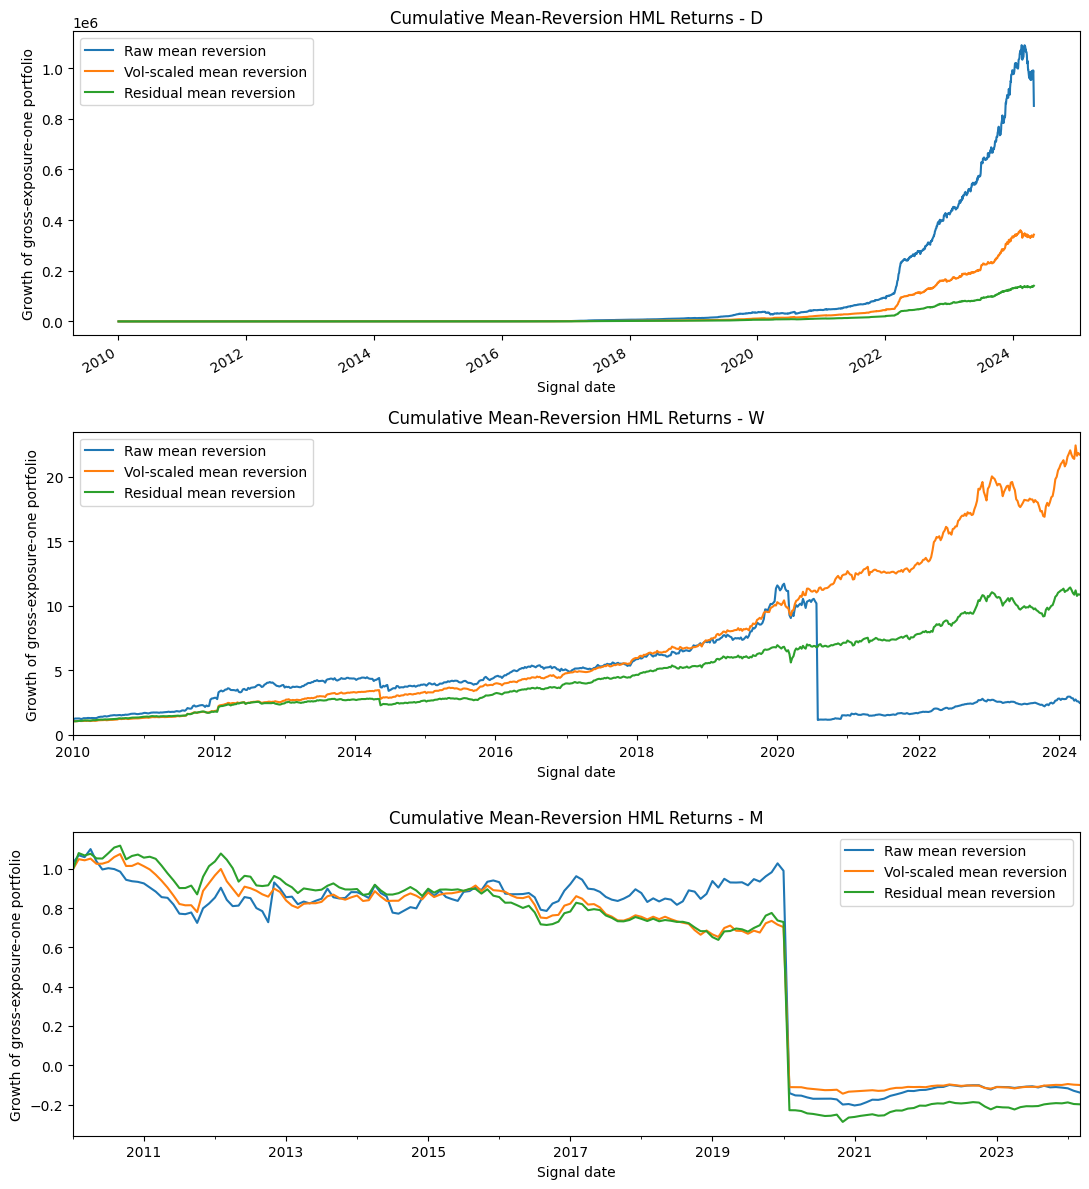

Worst HML periods


,period,signal,date,hml_return
0,D,Raw mean reversion,2024-04-29,-0.1402
1,D,Raw mean reversion,2020-08-05,-0.1017
2,D,Raw mean reversion,2012-05-02,-0.1012
3,D,Raw mean reversion,2020-03-16,-0.0881
4,D,Raw mean reversion,2015-03-04,-0.0865
10,D,Residual mean reversion,2015-03-04,-0.1011
11,D,Residual mean reversion,2020-02-17,-0.0723
12,D,Residual mean reversion,2020-08-03,-0.0537
13,D,Residual mean reversion,2012-01-25,-0.0519
14,D,Residual mean reversion,2012-12-20,-0.0506


Worst weekly raw mean-reversion event: 2020-07-31
Long leg tail


,signal,previous_period_return,next_period_return
id,,,
285,0.0687,-0.0687,-0.0369
27,0.0741,-0.0741,0.0015
233,0.0766,-0.0766,0.0270
91,0.0695,-0.0695,0.0280
176,0.0928,-0.0928,0.0313
254,0.1366,-0.1366,0.0424
76,0.0969,-0.0969,0.0725
281,0.0741,-0.0741,0.0768
302,0.0950,-0.0950,0.0962


Short leg tail


,signal,previous_period_return,next_period_return
id,,,
275,-0.0559,0.0559,16.0588
34,-0.0435,0.0435,0.1333
262,-0.1333,0.1333,0.0739
102,-0.0600,0.0600,0.0533
74,-0.0497,0.0497,0.0336
111,-0.0405,0.0405,0.0190
305,-0.0485,0.0485,0.0185
219,-0.0448,0.0448,-0.0095
155,-0.0393,0.0393,-0.0595


In [8]:
fig, axes = plt.subplots(len(GROUPING_PERIODS), 1, figsize=(11, 4 * len(GROUPING_PERIODS)), sharex=False)
if len(GROUPING_PERIODS) == 1:
    axes = [axes]

for ax, period in zip(axes, GROUPING_PERIODS):
    hml_returns = period_results[period]["hml_returns"]
    (1 + hml_returns).cumprod().plot(ax=ax)
    ax.set_title(f"Cumulative Mean-Reversion HML Returns - {period}")
    ax.set_xlabel("Signal date")
    ax.set_ylabel("Growth of gross-exposure-one portfolio")

plt.tight_layout()
plt.show()

worst_hml_events = []
for period, result in period_results.items():
    for signal_name in result["hml_returns"].columns:
        worst = result["hml_returns"][signal_name].dropna().nsmallest(5)
        for date, value in worst.items():
            worst_hml_events.append({"period": period, "signal": signal_name, "date": date, "hml_return": value})

worst_hml_events = pd.DataFrame(worst_hml_events).sort_values(["period", "signal", "hml_return"])
print("Worst HML periods")
display(worst_hml_events)


def hml_event_details(period: str, signal_name: str, date, n: int = 10) -> tuple[pd.DataFrame, pd.DataFrame]:
    result = period_results[period]
    signal = result["signals"][signal_name][0]
    signal_row = signal.loc[date].replace([np.inf, -np.inf], np.nan).dropna()
    n_leg = int(np.floor(len(signal_row) * HML_PORTFOLIO_FRACTION))
    ranked = signal_row.sort_values()
    short_ids = ranked.head(n_leg).index
    long_ids = ranked.tail(n_leg).index

    previous_return = result["stock_returns"].loc[date]
    next_return = result["stock_returns"].shift(-1).loc[date]

    long_leg = pd.DataFrame(
        {
            "signal": signal_row.reindex(long_ids),
            "previous_period_return": previous_return.reindex(long_ids),
            "next_period_return": next_return.reindex(long_ids),
        }
    ).sort_values("next_period_return")

    short_leg = pd.DataFrame(
        {
            "signal": signal_row.reindex(short_ids),
            "previous_period_return": previous_return.reindex(short_ids),
            "next_period_return": next_return.reindex(short_ids),
        }
    ).sort_values("next_period_return", ascending=False)

    return long_leg.head(n), short_leg.head(n)


worst_raw_weekly_date = period_results["W"]["hml_returns"]["Raw mean reversion"].dropna().idxmin()
weekly_raw_long_tail, weekly_raw_short_tail = hml_event_details("W", "Raw mean reversion", worst_raw_weekly_date, n=10)

print(f"Worst weekly raw mean-reversion event: {worst_raw_weekly_date.date()}")
print("Long leg tail")
display(weekly_raw_long_tail)
print("Short leg tail")
display(weekly_raw_short_tail)


## How to Read the Evidence

The evidence should be read from broad signal validity to portfolio realism.

1. **Coverage**: the average number of available stocks must be high enough for a cross-sectional test.
2. **IC**: a positive and significant IC means the rank ordering has predictive content.
3. **Regression slope**: a positive average slope confirms that the score has the expected sign in a linear test.
4. **HML return**: this shows whether the score survives a simple long-short translation.
5. **SPI beta**: a strong result with high SPI beta may be market exposure rather than stock-specific reversal.
6. **Tail events**: large losses reveal whether the strategy is robust or driven by a few extreme short positions.

The intended use of this notebook is not to claim that the HML portfolio is directly tradable. Instead, it tells us whether short-horizon reversal is worth carrying into the final Assignment 5 strategy as a controlled signal. If the signal is used later, it should be combined with liquidity screens, volatility scaling, turnover limits, and explicit transaction-cost assumptions.
